In [1]:
import pandas as pd
df = pd.read_csv('indian_roads_dataset.csv')

In [2]:
drop_cols = [
    "accident_id",
    "city",
    "state",
    "latitude",
    "longitude",
    "date",
    "time",
    "vehicles_involved",
    "casualties",
    "accident_severity",
    "cause",
    "traffic_density"
]

df_ml = df.drop(columns=drop_cols)

In [3]:
df_ml["festival"] = df_ml["festival"].fillna("No Festival")

In [4]:
X = df_ml.drop("risk_score", axis=1)

y = df_ml["risk_score"]

In [5]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features:")
print(cat_cols)

print("\nNumerical Features:")
print(num_cols)

Categorical Features:
['day_of_week', 'road_type', 'weather', 'visibility', 'festival']

Numerical Features:
['hour', 'is_weekend', 'lanes', 'traffic_signal', 'temperature', 'is_peak_hour']


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [7]:
#creating the encoder
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        )
    ],
    remainder="passthrough"
)

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
X_train_encoded = preprocessor.fit_transform(X_train) 
X_test_encoded = preprocessor.transform(X_test)

BEST MODEL : GRADIENT BOOSTING REGRESSOR

In [10]:
from sklearn.ensemble import GradientBoostingRegressor

In [11]:
gbr = GradientBoostingRegressor(
    random_state=42
)

gbr.fit(X_train_encoded, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [12]:
y_pred_gbr = gbr.predict(X_test_encoded)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("MAE :", mae_gbr)
print("RMSE:", rmse_gbr)
print("R² :", r2_gbr)

MAE : 0.10093006745890122
RMSE: 0.11418933875620513
R² : 0.7192912159932789


HYPERPARAMETER TUNING

In [15]:
from sklearn.model_selection import RandomizedSearchCV

In [16]:
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.8, 0.9, 1.0]
}

In [17]:
gb_random = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),

    param_distributions=param_dist,

    n_iter=30,

    scoring="r2",

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

In [18]:
gb_random.fit(X_train_encoded, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here...

In [19]:
print(gb_random.best_params_)

{'subsample': 1.0, 'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 2, 'learning_rate': 0.05}


In [20]:
print(gb_random.best_score_)

0.7265910665164721


In [21]:
best_gb = gb_random.best_estimator_

y_pred_best = best_gb.predict(X_test_encoded)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("MAE :", mae_best)
print("RMSE:", rmse_best)
print("R² :", r2_best)

MAE : 0.10083508694879534
RMSE: 0.1141796381592763
R² : 0.7193389074351231


FEATURE IMPORTANCE

In [22]:
feature_names = preprocessor.get_feature_names_out()

In [23]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_gb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
14,cat__visibility_low,0.498427
26,remainder__is_peak_hour,0.249126
10,cat__weather_clear,0.132158
13,cat__visibility_high,0.097923
21,remainder__hour,0.013485
15,cat__visibility_medium,0.004468
20,cat__festival_No Festival,0.001820
25,remainder__temperature,0.001044
23,remainder__lanes,0.000565
7,cat__road_type_highway,0.000286


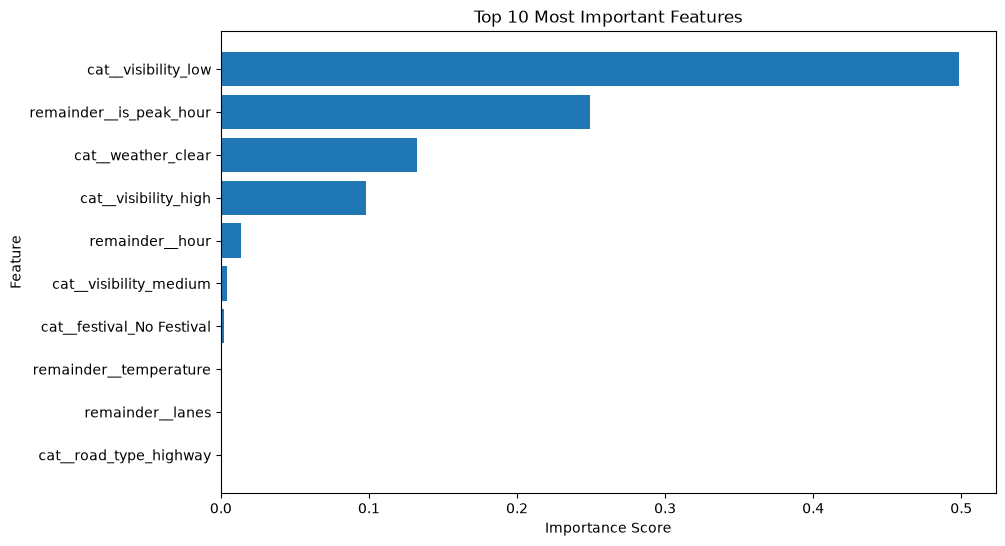

In [24]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

- Feature importance analysis indicates that visibility is the most influential factor in predicting the Route Safety Index, followed by peak-hour traffic and weather conditions. Features such as temperature, road type, and lane count contribute minimally to the prediction. These findings align with the exploratory data analysis, validating that adverse visibility and traffic congestion are the primary drivers of accident risk in the dataset.

- The tuned Gradient Boosting model identified visibility as the dominant predictor, contributing approximately 49.8% of the total feature importance. Peak-hour traffic accounted for approximately 24.9%, while weather conditions contributed 13.2%. Infrastructure-related features such as road type and lane count exhibited negligible influence, suggesting that environmental and temporal factors play a more significant role in determining accident risk within the given dataset.

SAVING THE BEST MODEL

In [25]:
import joblib

joblib.dump(best_gb, "best_gradient_boosting.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [26]:
import os

print(os.listdir())

['accident_prediction_india.csv', 'best_gradient_boosting.pkl', 'ds1.ipynb', 'ds2.ipynb', 'ds3.ipynb', 'eda.ipynb', 'feature_selection.ipynb', 'gbr.ipynb', 'indian_roads_dataset.csv', 'notebooks', 'preprocessor.pkl', 'Road.csv']


The trained Gradient Boosting model and preprocessing pipeline were serialized using Joblib for deployment and future inference.

In [27]:
loaded_model = joblib.load("best_gradient_boosting.pkl")
loaded_preprocessor = joblib.load("preprocessor.pkl")

BUILDING THE PREDICTION PIPELINE 

In [28]:
def predict_risk(input_df):
    # Preprocess
    processed = loaded_preprocessor.transform(input_df)

    # Predict
    prediction = loaded_model.predict(processed)

    return prediction[0]

In [33]:
route_features = pd.DataFrame({
    "day_of_week": ["Monday"],
    "road_type": ["urban"],
    "weather": ["rain"],
    "visibility": ["low"],
    "festival": ["No Festival"],
    "hour": [18],
    "is_weekend": [0],
    "lanes": [4],
    "traffic_signal": [1],
    "temperature": [30],
    "is_peak_hour": [1]
})

In [34]:
risk = predict_risk(route_features)

print(risk)

0.7576053682758692


ACTUAL VS PREDICTED PLOT

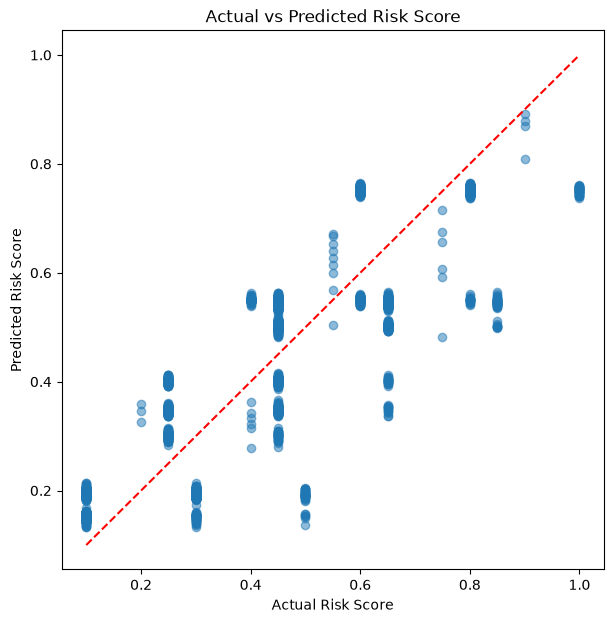

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_best, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")
plt.title("Actual vs Predicted Risk Score")

plt.show()

- The Actual vs Predicted plot shows that the Gradient Boosting model captures the overall trend of the risk scores effectively. Most predicted values lie close to the ideal diagonal line, indicating good predictive performance. Minor deviations are observed for very high-risk observations, suggesting that the model slightly underestimates extreme risk values. The horizontal bands occur because the target variable (risk_score) contains only a limited set of discrete values rather than a continuous range.

- The Actual vs Predicted analysis demonstrates a strong agreement between observed and predicted risk scores. The model achieves an R² score of approximately 0.72, indicating that it explains around 72% of the variance in the target variable. Prediction errors are relatively small, with larger deviations occurring primarily for high-risk observations.

RESIDUAL PLOT

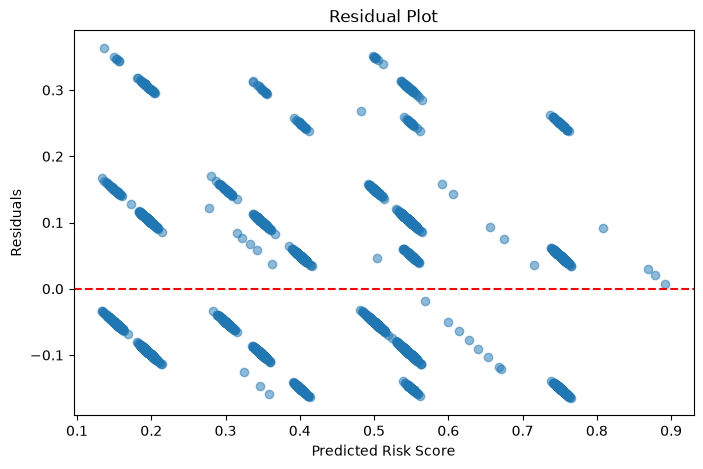

In [36]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8,5))

plt.scatter(y_pred_best, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Risk Score")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

- The residual plot shows that prediction errors are distributed around zero without a clear systematic trend, indicating that the model does not exhibit significant prediction bias. The diagonal banding pattern is expected because the target variable (risk_score) consists of a limited number of discrete values, resulting in quantized residuals rather than a continuous distribution.

- Residual analysis demonstrates that the Gradient Boosting model produces balanced prediction errors centered around zero. No significant systematic bias or heteroscedasticity was observed. The diagonal residual bands arise from the discretized nature of the target variable rather than deficiencies in the regression model.

RESIDUAL DISTRIBUTION HISTOGRAM

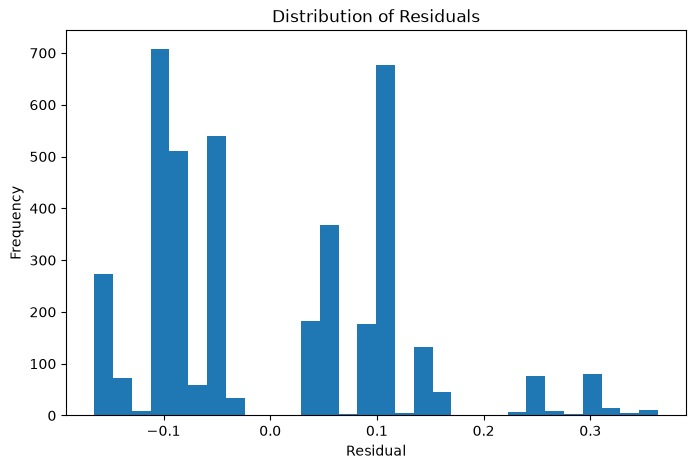

In [37]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

- The residual histogram shows that prediction errors are concentrated around zero with relatively few large errors. The multi-peaked distribution is expected because the target variable (risk_score) consists of discrete values rather than a continuous scale. Overall, the error distribution indicates stable and balanced model performance.

- The residual distribution confirms that the prediction errors are generally small and centered around zero. Although the distribution is not perfectly Gaussian, this behavior is attributed to the discretized target variable rather than model instability. The absence of substantial outliers suggests that the trained Gradient Boosting model provides consistent predictions across the dataset.

CONCLUSION 
- Five regression models were evaluated for predicting route risk scores. After comparison, the Gradient Boosting Regressor achieved the best overall performance. Hyperparameter tuning produced a slight improvement, resulting in a final R² score of approximately 0.719 with low MAE and RMSE values. Feature importance analysis identified low visibility, peak-hour traffic, and weather conditions as the most influential predictors. Residual analysis indicated balanced prediction errors without significant systematic bias.